In [1]:
from joblib import Parallel, delayed
import geopandas as gpd
from datetime import datetime
import re, os, json, time, warnings,joblib, glob, pickle, shap
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pathlib import Path
import numpy as np
import pandas as pd
from xgboost import XGBRegressor,XGBRFRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", message="Geometry is in a geographic CRS.*")
warnings.filterwarnings("ignore", message=".*invalid.* fixed.*", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="is_sparse is deprecated", category=FutureWarning)
warnings.filterwarnings("ignore", message="is_categorical_dtype is deprecated", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message="Geometry column does not contain geometry.")

### Before analysis ensure that the bands are remapped to colors

In [2]:
def remap_bands(gdp_file,out_path):
    S30={"B1":"CA","B2":"B","B3":"G","B4":"R","B8A":"NIR","B11":"SWIR1","B12":"SWIR2"}
    L8L30={"B1":"CA","B2":"B","B3":"G","B4":"R","B5":"NIR","B6":"SWIR1","B7":"SWIR2"}
    L7={"B1":"B","B2":"G","B3":"R","B4":"NIR","B5":"SWIR1","B7":"SWIR2"}
    gdf = gpd.read_file(gdp_file)
    gcol=getattr(gdf.geometry,'name','geometry')
    keep=[c for c in ("DW_label","L7_Date","L8_date",gcol) if c in gdf.columns]
    ren={}
    for c in gdf.columns:
        if c in keep: continue
        m=re.match(r'^(S30|L8|L30|L7)(?:_SR)?_(B\d{1,2}|B8A)$', c)
        if not m: continue
        s, b = m.group(1), m.group(2)
        mp = S30 if s=="S30" else (L8L30 if s in ("L8","L30") else L7)
        if b in mp: ren[c]=f"{s}_{mp[b]}"
    cols=keep+[c for c in gdf.columns if c in ren]
    out_gdf = gpd.GeoDataFrame(gdf[cols].rename(columns=ren), geometry=gcol, crs=getattr(gdf, 'crs', None))
    out_gdf.to_file(out_path, driver="ESRI Shapefile", index=False)
    return out_gdf

### Step 1. How many points are enough?
Using an XGB model, determine how many points are enough by iteravely adding points

In [3]:
gdf=gpd.read_file(r'E:\GIS\Landcover_sampling\Intermediate\remapped3mill_Global_final.shp')

In [3]:
def xgb_size_curve_by_breakup(df, outdir, X1, Y1, X2, Y2, breakup_amount, seed=71, max_increments=None):
    def _bands_for_target(t): return ["B","G","R","NIR","SWIR1","SWIR2"] if str(t).upper()=="L8" else ["CA","B","G","R","NIR","SWIR1","SWIR2"]
    t0=datetime.now(); print(f"Loaded {len(df):,} rows, {len(df.columns)} cols"); os.makedirs(outdir,exist_ok=True)
    rmse=lambda y,yh: float(np.sqrt(mean_squared_error(y,yh)))
    if "geometry" not in df: raise ValueError("Need 'geometry'")
    lon = pd.to_numeric(getattr(df.geometry, "x", pd.Series(np.nan, index=df.index)), errors="coerce")
    lat = pd.to_numeric(getattr(df.geometry, "y", pd.Series(np.nan, index=df.index)), errors="coerce")
    if lon.isna().all() or lat.isna().all():
        c = df["geometry"].astype(str).str.extract(r"POINT\s*\(\s*([+-]?\d+(?:\.\d+)?)\s+([+-]?\d+(?:\.\d+)?)\s*\)")
        lon, lat = pd.to_numeric(c[0], errors="coerce"), pd.to_numeric(c[1], errors="coerce")
    li, la = np.floor(lon.fillna(0)).astype(int), np.floor(lat.fillna(0)).astype(int)
    mtest = (li % 2 == 0) & (la % 2 == 0)
    mval  = (li % 2 != 0) & (la % 2 != 0)
    mtrain = ~(mtest | mval)
    tr,va=df.loc[mtrain].copy(),df.loc[mval].copy(); print(f"Split -> train={len(tr):,}, val={len(va):,}")
    rng = np.random.default_rng(seed)
    tr = tr.iloc[rng.permutation(len(tr))].reset_index(drop=True)
    va = va.iloc[rng.permutation(len(va))].reset_index(drop=True)
    bands1,bands2=_bands_for_target(Y1),_bands_for_target(Y2)
    pick=lambda fr,ps,bnds:[f"{p}_{b}" for p in ps for b in bnds if f"{p}_{b}" in fr.columns]
    TX1,VX1=tr[pick(tr,[X1],bands1)],va[pick(va,[X1],bands1)]
    TX2,VX2=tr[pick(tr,[X2],bands2)],va[pick(va,[X2],bands2)]
    Y1tr,Y1va=pick(tr,[Y1],bands1),pick(va,[Y1],bands1)
    Y2tr,Y2va=pick(tr,[Y2],bands2),pick(va,[Y2],bands2)
    F2tr=pd.concat([TX2,tr[Y1tr]],axis=1) if Y1tr else TX2
    F2va=pd.concat([VX2,va[Y1va]],axis=1) if Y1va else VX2
    ntr,nva=len(tr),len(va)
    last_full_tr=(ntr//breakup_amount)*breakup_amount
    vbreak=max(1,breakup_amount//2)
    last_full_va=(nva//vbreak)*vbreak
    sizes_tr=list(range(breakup_amount,last_full_tr+1,breakup_amount)) if last_full_tr else []
    sizes_va=list(range(vbreak,last_full_va+1,vbreak)) if last_full_va else ([0] if nva else [])
    if max_increments is not None and max_increments>0:
        sizes_tr=sizes_tr[:max_increments]; sizes_va=sizes_va[:max_increments] if sizes_va else sizes_va
    if not sizes_tr: print(f"No full steps fit into train_n={ntr} with breakup_amount={breakup_amount}. Writing empty CSV.")
    rows=[]; print(f"Training across {len(sizes_tr)} increments (breakup={breakup_amount})")
    for i,n_take in enumerate(sizes_tr,1):
        n_val=sizes_va[min(i-1,len(sizes_va)-1)] if sizes_va else 0
        print(f" Step {i}/{len(sizes_tr)}: train_n={n_take}, val_n={n_val}")
        r1,r2=[],[]
        for tgt in Y1tr:
            ti=np.flatnonzero(tr[tgt].notna().to_numpy()); vi=np.flatnonzero(va[tgt].notna().to_numpy())
            if ti.size and vi.size and n_val>0:
                Xtr,ytr=TX1.iloc[ti[:n_take]].to_numpy(np.float32),tr[tgt].iloc[ti[:n_take]].to_numpy(np.float32)
                Xva,yva=VX1.iloc[vi[:n_val]].to_numpy(np.float32),va[tgt].iloc[vi[:n_val]].to_numpy(np.float32)
                m=XGBRFRegressor(random_state=seed,n_jobs=-1); m.fit(Xtr,ytr); r1.append(rmse(yva,m.predict(Xva)))
        for tgt in Y2tr:
            ti=np.flatnonzero(tr[tgt].notna().to_numpy()); vi=np.flatnonzero(va[tgt].notna().to_numpy())
            if ti.size and vi.size and n_val>0:
                Xtr2,ytr2=F2tr.iloc[ti[:n_take]].to_numpy(np.float32),tr[tgt].iloc[ti[:n_take]].to_numpy(np.float32)
                Xva2,yva2=F2va.iloc[vi[:n_val]].to_numpy(np.float32),va[tgt].iloc[vi[:n_val]].to_numpy(np.float32)
                m2=XGBRFRegressor(random_state=seed,n_jobs=-1); m2.fit(Xtr2,ytr2); r2.append(rmse(yva2,m2.predict(Xva2)))
        rows.append({"total_added":i*breakup_amount,"breakup_amount":breakup_amount,"train_n":int(n_take),"val_n":int(n_val),
                     "mean_RMSE1":(float(np.nanmean(r1)) if r1 else np.nan),
                     "mean_RMSE2":(float(np.nanmean(r2)) if r2 else np.nan),
                     "targets1_used":len(r1),"targets2_used":len(r2)})
    curve=pd.DataFrame(rows); out_csv=os.path.join(outdir,"size_curve_xgbrf.csv"); curve.to_csv(out_csv,index=False)
    print(f"Wrote CSV: {out_csv} Time: {(datetime.now()-t0).seconds/60:.2f} min"); return out_csv

def plot_size_curve(csv_path, out_png=None, xlab="Training points", ylab="Mean RMSD",
                    x1y1_label="ETM+/OLI", y1y2_label="HLS"):
    print(f"Reading CSV for plotting: {csv_path}")
    df = pd.read_csv(csv_path)
    if out_png is None:
        out_png = os.path.splitext(csv_path)[0] + ".jpg"
    plt.figure(figsize=(6,4.5))
    if "mean_RMSE1" in df and df["mean_RMSE1"].notna().any():
        plt.plot(df["train_n"], df["mean_RMSE1"], color="#00796B", linewidth=1, marker="o", label=x1y1_label)
    if "mean_RMSE2" in df and df["mean_RMSE2"].notna().any():
        plt.plot(df["train_n"], df["mean_RMSE2"], color="#56B4E9", linewidth=1, marker="o", label=y1y2_label)
    ax = plt.gca()
    plt.xlabel(xlab, fontsize=14)
    plt.ylabel(ylab, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12, frameon=False)
    plt.tight_layout()
    plt.savefig(out_png, dpi=400)
    plt.show()
    print(f"Saved plot: {out_png}")
    return out_png

In [12]:
def plot_size_curve(csv_path, out_png=None, xlab="Training Points", ylab="Mean RMSD",
                    x1y1_label="ETM+/OLI", y1y2_label="HLS 2.0"):
    print(f"Reading CSV for plotting: {csv_path}")
    df = pd.read_csv(csv_path)
    if out_png is None:
        out_png = os.path.splitext(csv_path)[0] + ".jpg"
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
    target_x = 500_000  # training points to highlight
    band_height = 0.0001  # total height of the grey box in y-units
    half_band = band_height
    # -------- left panel (ETM+/OLI) --------
    ax1 = axes[0]
    if "mean_RMSE1" in df.columns and df["mean_RMSE1"].notna().any():
        ax1.plot(df["train_n"], df["mean_RMSE1"], color="black", linewidth=1, marker="o")
        ax1.scatter(df["train_n"], df["mean_RMSE1"], s=18, color="black", zorder=3)
        sub1 = df.loc[df["train_n"] == target_x, "mean_RMSE1"].dropna()
        if not sub1.empty:
            yref1 = float(sub1.iloc[0])
            # grey band centered on the 500,000-point y-value
            ax1.axhspan(yref1 - half_band, yref1 + half_band,color="grey", alpha=0.25, zorder=0)
            # highlight the point at 500,000 in red
            ax1.scatter([target_x], [yref1], s=60, color="red", zorder=4)
    else:
        ax1.text(0.5, 0.5, "No mean_RMSE1 data", ha="center", va="center", transform=ax1.transAxes)
    ax1.set_xlabel(xlab, fontsize=14)
    ax1.set_ylabel(ylab, fontsize=14)  # only one y-label
    ax1.set_title(x1y1_label, fontsize=14)
    ax1.tick_params(axis="both", labelsize=12)
    ax1.yaxis.set_major_locator(MultipleLocator(0.0001))
    # -------- right panel (HLS) --------
    ax2 = axes[1]
    if "mean_RMSE2" in df.columns and df["mean_RMSE2"].notna().any():
        ax2.plot(df["train_n"], df["mean_RMSE2"], color="black", linewidth=1, marker="o")
        ax2.scatter(df["train_n"], df["mean_RMSE2"], s=18, color="black", zorder=3)
        sub2 = df.loc[df["train_n"] == target_x, "mean_RMSE2"].dropna()
        if not sub2.empty:
            yref2 = float(sub2.iloc[0])
            # grey band centered on the 500,000-point y-value
            ax2.axhspan(
                yref2 - half_band, yref2 + half_band,
                color="grey", alpha=0.25, zorder=0)
            ax2.scatter([target_x], [yref2], s=60, color="red", zorder=4)
    else:
        ax2.text(0.5, 0.5, "No mean_RMSE2 data", ha="center", va="center", transform=ax2.transAxes)
    ax2.set_xlabel(xlab, fontsize=14)
    ax2.set_title(y1y2_label, fontsize=14)
    ax2.tick_params(axis="both", labelsize=12)
    ax2.set_ylabel("")  # no right y-label
    ax2.yaxis.set_major_locator(MultipleLocator(0.0001))
    fig.tight_layout()
    plt.savefig(out_png, dpi=400)
    plt.show()
    print(f"Saved plot: {out_png}")
    return out_png

Reading CSV for plotting: E:\GIS\Landcover_sampling\Intermediate\size_curve_xgbrf.csv


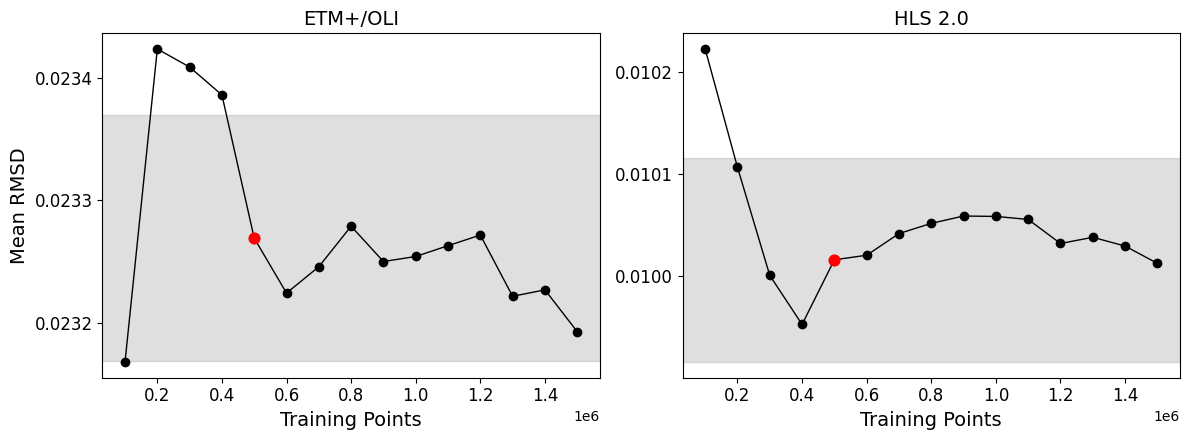

Saved plot: E:\GIS\Landcover_sampling\Figures\Fig_howmuch.png


'E:\\GIS\\Landcover_sampling\\Figures\\Fig_howmuch.png'

In [13]:
#uncomment to run code
#csv_path = xgb_size_curve_by_breakup(gdf,r'E:\GIS\Landcover_sampling\Intermediate',X1="L7", Y1="L8", X2="L30", Y2="S30",breakup_amount=100000, max_increments=15)
plot_size_curve(r'E:\GIS\Landcover_sampling\Intermediate\size_curve_xgbrf.csv'
                ,out_png=r'E:\GIS\Landcover_sampling\Figures\Fig_howmuch.png')

### Step 2. Dataset split to CSV
Split dataset using Lat Long to training and test datasets

In [6]:
def split_and_sample_to_csv_counts(df, outdir, n_train, n_val, n_test, seed=71,
                                   drop_cols=("L7_Date",'L8_date', 'QA_PIXEL', 'QA_RADSAT','Fmask',"SR_ATMOS_O","SR_QA_AERO")):
    os.makedirs(outdir, exist_ok=True); print(f"Starting split; targets train={n_train}, val={n_val}, test={n_test}")
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True); print(f"Shuffled df: {len(df):,} rows")
    df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
    if "geometry" in df.columns:
        try: lon, lat = pd.to_numeric(df.geometry.x, errors="coerce"), pd.to_numeric(df.geometry.y, errors="coerce")
        except Exception:
            c = df["geometry"].astype(str).str.extract(r"POINT\s*\(\s*([+-]?\d+(?:\.\d+)?)\s+([+-]?\d+(?:\.\d+)?)\s*\)"); lon, lat = pd.to_numeric(c[0], errors="coerce"), pd.to_numeric(c[1], errors="coerce")
    else: raise ValueError("Need 'geometry' or one of {'L8_image_id','L8_image_i'} to split.")
    li, la = np.floor(lon.fillna(0)).astype(int), np.floor(lat.fillna(0)).astype(int)
    mtest = (li % 2 == 0) & (la % 2 == 0)
    mval  = (li % 2 != 0) & (la % 2 != 0)
    mtrain = ~(mtest | mval)
    base_train, base_val, base_test = df.loc[mtrain].copy(), df.loc[mval].copy(), df.loc[mtest].copy()
    print(f"Base sizes -> train={len(base_train):,}, val={len(base_val):,}, test={len(base_test):,}")
    ktr, kva, kte = min(n_train, len(base_train)), min(n_val, len(base_val)), min(n_test, len(base_test))
    if (ktr, kva, kte) != (n_train, n_val, n_test): print(f"[WARN] Capped -> train={ktr}, val={kva}, test={kte}")
    if "geometry" in base_train.columns:
        for fr in (base_train, base_val, base_test): fr["geometry"] = fr["geometry"].apply(lambda g: getattr(g, "wkt", None))
    train = base_train.sample(n=ktr, random_state=seed,   replace=False) if ktr>0 else base_train.iloc[0:0]
    val   = base_val.sample(n=kva,   random_state=seed, replace=False) if kva>0 else base_val.iloc[0:0]
    test  = base_test.sample(n=kte,  random_state=seed, replace=False) if kte>0 else base_test.iloc[0:0]
    out_train, out_val, out_test = (os.path.join(outdir, "train.csv"), os.path.join(outdir, "val.csv"), os.path.join(outdir, "test.csv"))
    train.to_csv(out_train, index=False); val.to_csv(out_val, index=False); test.to_csv(out_test, index=False)
    print(f"Wrote:\n  {out_train} ({len(train):,})\n  {out_val} ({len(val):,})\n  {out_test} ({len(test):,})")

In [9]:
split_and_sample_to_csv_counts(gdf, r'E:\GIS\Landcover_sampling\Intermediate',
                               n_train=1_000_000, n_val=500_000, n_test=500_000)

Starting split; targets train=1000000, val=500000, test=500000
Shuffled df: 3,134,113 rows
Base sizes -> train=1,568,134, val=777,386, test=788,593
Wrote:
  E:\GIS\Landcover_sampling\Intermediate\train.csv (1,000,000)
  E:\GIS\Landcover_sampling\Intermediate\val.csv (500,000)
  E:\GIS\Landcover_sampling\Intermediate\test.csv (500,000)


### Step 3. Train models to Outputs
Train models and write to output txt files or folders containing pickles (with and without landcovers)

In [7]:
L7L8_BANDS   = ["B","G","R","NIR","SWIR1","SWIR2"]
S30L30_BANDS = ["CA","B","G","R","NIR","SWIR1","SWIR2"]
_fmt_lin  = lambda a,b,x,y: f"{y} = {a:.4f}{x} {'+' if b>=0 else '-'} {abs(b):.4f}"
_fmt_mlr  = lambda coefs,b0,bands,x,y: f"{y} = " + " ".join(f"{c:+.4f}*{x}_{bn}" for c,bn in zip(coefs,bands)) + f" {b0:+.4f}"
_numcols  = lambda df, cols: df.assign(**{c: pd.to_numeric(df[c],errors="coerce") for c in cols if c in df})
def _fit_ols_per_band(df, px, py, bands):
    df=_numcols(df.copy(), [f"{px}_{b}" for b in bands]+[f"{py}_{b}" for b in bands]); res={}
    for b in bands:
        x,y=df.get(f"{px}_{b}"),df.get(f"{py}_{b}")
        if x is None or y is None: continue
        m=np.isfinite(x)&np.isfinite(y)
        if m.sum()<2: continue
        a,b0=np.polyfit(x[m],y[m],1).astype(float); res[b]=(a,b0)
    return res
def _fit_mlr(df, px, py, bands):
    df=_numcols(df.copy(), [f"{px}_{b}" for b in bands]+[f"{py}_{b}" for b in bands]); out={}
    X=np.column_stack([df[f"{px}_{b}"] for b in bands]) if bands else None
    for t in bands:
        y=df.get(f"{py}_{t}"); 
        if X is None or y is None: continue
        M=np.isfinite(X).all(1)&np.isfinite(y.values); 
        if M.sum()<len(bands)+1: continue
        Xb=np.column_stack([X[M],np.ones(M.sum())]); beta,*_=np.linalg.lstsq(Xb,y.values[M],rcond=None)
        out[t]=(beta[:-1].astype(float),float(beta[-1]))
    return out
def fit_and_write_regressions(train_csv, val_csv, out_txt):
    df=pd.concat([pd.read_csv(train_csv),pd.read_csv(val_csv)],ignore_index=True)
    pairs=[("L7","L8",L7L8_BANDS,"LS7","LS8"),("S30","L30",S30L30_BANDS,"S30","L30")]
    lines=["=== OLS Regression ==="]
    t_ols_start = time.perf_counter()  # timing
    for i,(px,py,bands,xlab,ylab) in enumerate(pairs):
        lines+=([f"-- {xlab} to {ylab} --"] if i==0 else ["",f"-- {xlab} to {ylab} --"])
        ols=_fit_ols_per_band(df,px,py,bands)
        lines+=[f"{b}: "+_fmt_lin(*ols[b],xlab,ylab) for b in bands if b in ols]
    t_ols = time.perf_counter() - t_ols_start  # timing
    lines+=["","=== MLR Regression (multi-band) ==="]
    t_mlr_start = time.perf_counter()  # timing
    for i,(px,py,bands,xlab,ylab) in enumerate(pairs):
        lines+=([f"-- {xlab} to {ylab} --"] if i==0 else ["",f"-- {xlab} to {ylab} --"])
        mlr=_fit_mlr(df,px,py,bands)
        lines+=[f"{b}: "+_fmt_mlr(*mlr[b],bands,xlab,ylab) for b in bands if b in mlr]
    t_mlr = time.perf_counter() - t_mlr_start  # timing
    open(out_txt,"w",encoding="utf-8").write("\n".join(lines))
    print(f"Wrote regressions to: {out_txt}")
    print(f"OLS took {t_ols:.3f} seconds, MLR took {t_mlr:.3f} seconds")  # timing
def fit_and_write_regressions_per_LC(train_csv, val_csv, out_txt):
    df=pd.concat([pd.read_csv(train_csv),pd.read_csv(val_csv)],ignore_index=True)
    if "DW_label" not in df: raise SystemExit("DW_label column not found.")
    pairs=[("L7","L8",L7L8_BANDS,"LS7","LS8"),("S30","L30",S30L30_BANDS,"S30","L30")]
    classes=sorted(df["DW_label"].dropna().unique())
    lines=["=== OLS Regression ==="]
    t_ols_start = time.perf_counter()  # timing
    for j,(px,py,bands,xlab,ylab) in enumerate(pairs):
        lines+=([] if j==0 else [""]); lines+=[f"-- {xlab} to {ylab} --"]
        for c in classes:
            dfs=df[df["DW_label"]==c]; ols=_fit_ols_per_band(dfs,px,py,bands)
            lines+=[f"class {c} (N: {len(dfs)})"]+[f"{b}: "+_fmt_lin(*ols[b],xlab,ylab) for b in bands if b in ols]
    t_ols = time.perf_counter() - t_ols_start  # timing

    lines+=["","=== MLR Regression (multi-band) ==="]
    t_mlr_start = time.perf_counter()  # timing
    for j,(px,py,bands,xlab,ylab) in enumerate(pairs):
        lines+=([] if j==0 else [""]); lines+=[f"-- {xlab} to {ylab} --"]
        for c in classes:
            dfs=df[df["DW_label"]==c]; mlr=_fit_mlr(dfs,px,py,bands)
            lines+=[f"class {c} (N: {len(dfs)})"]+[f"{b}: "+_fmt_mlr(*mlr[b],bands,xlab,ylab) for b in bands if b in mlr]
    t_mlr = time.perf_counter() - t_mlr_start  # timing
    open(out_txt,"w",encoding="utf-8").write("\n".join(lines))
    print(f"Wrote per-class regressions to: {out_txt}")
    print(f"OLS took {t_ols:.3f} seconds, MLR took {t_mlr:.3f} seconds")  # timing

In [11]:
train=r"E:\GIS\Landcover_sampling\Intermediate\train.csv"
val=r"E:\GIS\Landcover_sampling\Intermediate\val.csv"
fit_and_write_regressions(train,val,r"E:\GIS\Landcover_sampling\Intermediate\global_models\regressions.txt")
fit_and_write_regressions_per_LC(train,val,r"E:\GIS\Landcover_sampling\Intermediate\global_models\regressions_LC.txt")

Wrote regressions to: E:\GIS\Landcover_sampling\Intermediate\global_models\regressions.txt
OLS took 1.642 seconds, MLR took 2.960 seconds
Wrote per-class regressions to: E:\GIS\Landcover_sampling\Intermediate\global_models\regressions_LC.txt
OLS took 2.179 seconds, MLR took 3.600 seconds


In [8]:
def train_bandwise_models(df_tr, df_va, out_dir, dataset, use_dw, regressor, learning_rates,
                          n_estimators_list, seed=71, n_jobs=-1, enable_fi=False):
    os.makedirs(out_dir, exist_ok=True); log_path=os.path.join(out_dir,"logs.txt")
    log=lambda s:(print(s),open(log_path,"a",encoding="utf-8").write(s+"\n")); open(log_path,"a",encoding="utf-8").write("\n")
    if dataset not in ("l7l8","s30l30"): raise ValueError("dataset must be 'l7l8' or 's30l30'")
    bands,(Xp,yp)= (["B","G","R","NIR","SWIR1","SWIR2"],("L7_","L8_")) if dataset=="l7l8" else (["CA","B","G","R","NIR","SWIR1","SWIR2"],("S30_","L30_"))
    Xbase=[f"{Xp}{b}" for b in bands if b!="CA" or dataset=="s30l30"]
    # helpers
    to_num=lambda d,cols:[d.__setitem__(c,pd.to_numeric(d[c],errors="coerce")) for c in cols if c!="DW_label" and c in d.columns]
    tag=lambda lr:f"{lr:.0e}".replace("e-0","e-").replace("e+0","e+")
    rmsr2=lambda m,X,y:(float(np.sqrt(mean_squared_error(y,m.predict(X)))),float(r2_score(y,m.predict(X))))
    feats=set(Xbase)|({"DW_label"} if use_dw else set()); targs={f"{yp}{b}" for b in bands}
    to_num(df_tr, feats|targs); to_num(df_va, feats|targs)
    # lock DW categories across splits (needed for OHE)
    if use_dw and "DW_label" in df_tr and "DW_label" in df_va:
        cats=sorted(pd.unique(pd.concat([df_tr["DW_label"],df_va["DW_label"]],ignore_index=True).dropna()))
        df_tr["DW_label"]=pd.Categorical(df_tr["DW_label"],categories=cats)
        df_va["DW_label"]=pd.Categorical(df_va["DW_label"],categories=cats)
    t0=time.perf_counter()
    search_sum=0.0
    train_sum=0.0
    fi_rows=[]
    shap_rows=[]
    for band in bands:
        X=Xbase.copy()
        if dataset=="s30l30" and band=="CA" and f"{Xp}CA" not in X: X.insert(0,f"{Xp}CA")
        if use_dw and "DW_label" in df_tr.columns: X.append("DW_label")
        ytr,yva=df_tr.get(f"{yp}{band}"), df_va.get(f"{yp}{band}")
        if ytr is None or yva is None:
            log(f"[skip] band={band} missing {yp}{band}"); continue
        num=[c for c in X if c!="DW_label"]
        mtr=(df_tr[num].apply(np.isfinite).all(1) if num else True) & (df_tr["DW_label"].notna() if "DW_label" in X else True) & np.isfinite(ytr)
        mva=(df_va[num].apply(np.isfinite).all(1) if num else True) & (df_va["DW_label"].notna() if "DW_label" in X else True) & np.isfinite(yva)
        Xtr, Xva = df_tr.loc[mtr, X].copy(), df_va.loc[mva, X].copy(); ytr_, yva_ = ytr[mtr].to_numpy(), yva[mva].to_numpy()
        if len(ytr_)<5 or len(yva_)<2:
            log(f"[skip] band={band} insufficient data (train={len(ytr_)}, val={len(yva_)})"); continue
        # One-hot encode DW_label for RF; keep native categorical for XGB
        use_ohe = (regressor=="RF") and ("DW_label" in X)
        if use_ohe:
            Xtr=pd.get_dummies(Xtr, columns=["DW_label"], dtype=float); Xva=pd.get_dummies(Xva, columns=["DW_label"], dtype=float)
            Xva=Xva.reindex(columns=Xtr.columns, fill_value=0.0)
        feats_list=list(Xtr.columns)
        enable_cat = (regressor=="XGB") and ("DW_label" in X)
        # search
        best=None; tS=time.perf_counter()
        if regressor=="RF":
            for n in n_estimators_list:
                mdl=XGBRFRegressor(n_estimators=n, objective="reg:squarederror", random_state=seed, n_jobs=n_jobs, tree_method="hist", enable_categorical=False)
                mdl.fit(Xtr, ytr_); rmse,r2=rmsr2(mdl,Xva,yva_); key=(rmse,-r2); best=(rmse,-r2,{"model":"RF","n":n}) if best is None or key<best[:2] else best
        elif regressor=="XGB":
            for lr in learning_rates:
                for n in n_estimators_list:
                    mdl=XGBRegressor(n_estimators=n, learning_rate=lr, objective="reg:squarederror", random_state=seed, n_jobs=n_jobs, tree_method="hist", enable_categorical=enable_cat)
                    mdl.fit(Xtr, ytr_); rmse,r2=rmsr2(mdl,Xva,yva_); key=(rmse,-r2); best=(rmse,-r2,{"model":"XGB","n":n,"lr":lr}) if best is None or key<best[:2] else best
        else: raise ValueError("regressor must be 'RF' or 'XGB'")
        search_sum+=time.perf_counter()-tS
        if best is None:
            log(f"[skip] band={band} no valid model"); continue
        # final fit on all data (respect encoding)
        df_all=pd.concat([df_tr,df_va],ignore_index=True); to_num(df_all,[*X,f"{yp}{band}"])
        if "DW_label" in X and not isinstance(df_all["DW_label"].dtype,pd.CategoricalDtype): df_all["DW_label"]=pd.Categorical(df_all["DW_label"],categories=cats)
        mall=(df_all[num].apply(np.isfinite).all(1) if num else True) & (df_all["DW_label"].notna() if "DW_label" in X else True) & np.isfinite(df_all[f"{yp}{band}"])
        Xall=df_all.loc[mall, X].copy(); yall=df_all.loc[mall,f"{yp}{band}"].to_numpy()
        if use_ohe:
            Xall=pd.get_dummies(Xall, columns=["DW_label"], dtype=float); Xall=Xall.reindex(columns=feats_list, fill_value=0.0)
        p=best[2]; regS=p["model"]; dwtag="_DW" if ("DW_label" in X) else ""
        if regS=="RF":
            final=XGBRFRegressor(n_estimators=p["n"], objective="reg:squarederror", random_state=seed, n_jobs=n_jobs)
            fname=f"{regS}_{dataset}{dwtag}_{band}_n{p['n']}.pkl"
        else:
            final=XGBRegressor(n_estimators=p["n"], learning_rate=p["lr"], objective="reg:squarederror", random_state=seed, n_jobs=n_jobs, enable_categorical=enable_cat)
            fname=f"{regS}_{dataset}{dwtag}_{band}_n{p['n']}_lr{tag(p['lr'])}.pkl"
        t_train = time.perf_counter()
        final.fit(Xall, yall)
        train_sum += time.perf_counter()-t_train
        joblib.dump(final, os.path.join(out_dir,fname))
        rmse,r2=best[0],-best[1]
        log(f"ds={dataset} {'DW' if use_dw else 'noDW'} reg={regS} band={band} | best={json.dumps(p)} | val_RMSE={rmse:.5f} val_R2={r2:.5f} | saved={fname}")
        if enable_fi:
            fi_rows.append(_fi_row(final, feats_list, band, X_for_shap=Xall, shap_rows=shap_rows))
    if enable_fi:
        if fi_rows:
            cols={"band"}; [cols.update(r.keys()) for r in fi_rows]; cols=["band"]+sorted([c for c in cols if c!="band"])
            fi_df=pd.DataFrame(fi_rows).reindex(columns=cols).fillna(0.0); fi_name=f"FI_{dataset}_{regressor}{'_DW' if use_dw else ''}.csv"
            fi_df.to_csv(os.path.join(out_dir,fi_name), index=False); log(f"[FI] saved feature-importance matrix: {fi_name} ({len(fi_df)} bands, {fi_df.shape[1]-1} FI columns)")
        else: log("[FI] no feature-importance rows produced")
        if shap_rows:
            shap_df = pd.DataFrame(shap_rows)
            cols = ["band"] + sorted([c for c in shap_df.columns if c!="band"])
            shap_df = shap_df.reindex(columns=cols)
            shap_name = f"SHAP_{dataset}_{regressor}{'_DW' if use_dw else ''}.csv"
            shap_df.to_csv(os.path.join(out_dir, shap_name), index=False)
            log(f"[SHAP] saved SHAP matrix: {shap_name} ({len(shap_df)} rows, {shap_df.shape[1]-1} SHAP columns)")
        else: log("[SHAP] no SHAP rows produced")
    total_elapsed = time.perf_counter()-t0
    log(f"SUMMARY | ds={dataset} {'DW' if use_dw else 'noDW'} reg={regressor} | grid_search_time={search_sum:.2f}s | train_time={train_sum:.2f}s | total_elapsed={total_elapsed:.2f}s")
    print(f"Grid search time (all bands): {search_sum:.2f}s")
    print(f"Final model training time (all bands): {train_sum:.2f}s")

In [13]:
train_csv=r"E:\GIS\Landcover_sampling\Intermediate\train.csv"
val_csv=r"E:\GIS\Landcover_sampling\Intermediate\val.csv"
out_dir=r"E:\GIS\Landcover_sampling\Intermediate\global_models"
df_tr=pd.read_csv(train_csv); df_va=pd.read_csv(val_csv)
n_estimators_list=(50, 100, 250, 500, 1000)
learning_rates=(0.0001, 0.001, 0.01, 0.1)
datasets=("l7l8","s30l30")
regressors=("RF","XGB")
use_dw_flags=(False,True)
for ds in datasets:
    for rg in regressors:
        for dw in use_dw_flags:
            train_bandwise_models(df_tr,df_va,out_dir,dataset=ds,use_dw=dw,regressor=rg,learning_rates=learning_rates,n_estimators_list=n_estimators_list)

ds=l7l8 noDW reg=RF band=B | best={"model": "RF", "n": 1000} | val_RMSE=0.01455 val_R2=0.92950 | saved=RF_l7l8_B_n1000.pkl
ds=l7l8 noDW reg=RF band=G | best={"model": "RF", "n": 100} | val_RMSE=0.01659 val_R2=0.95543 | saved=RF_l7l8_G_n100.pkl
ds=l7l8 noDW reg=RF band=R | best={"model": "RF", "n": 1000} | val_RMSE=0.01920 val_R2=0.97384 | saved=RF_l7l8_R_n1000.pkl
ds=l7l8 noDW reg=RF band=NIR | best={"model": "RF", "n": 250} | val_RMSE=0.03145 val_R2=0.91202 | saved=RF_l7l8_NIR_n250.pkl
ds=l7l8 noDW reg=RF band=SWIR1 | best={"model": "RF", "n": 1000} | val_RMSE=0.03090 val_R2=0.95897 | saved=RF_l7l8_SWIR1_n1000.pkl
ds=l7l8 noDW reg=RF band=SWIR2 | best={"model": "RF", "n": 1000} | val_RMSE=0.02555 val_R2=0.97175 | saved=RF_l7l8_SWIR2_n1000.pkl
SUMMARY | ds=l7l8 noDW reg=RF | grid_search_time=293.32s | train_time=160.02s | total_elapsed=456.00s
Grid search time (all bands): 293.32s
Final model training time (all bands): 160.02s
ds=l7l8 DW reg=RF band=B | best={"model": "RF", "n": 1000} 

### Step 4. Evaluate Models
Evaluate all the models on test dataset, and write a csv of results (with and without landcovers)

In [9]:
# ---------- small utils ----------
L7L8 = ["B","G","R","NIR","SWIR1","SWIR2"]
S30L30 = ["CA","B","G","R","NIR","SWIR1","SWIR2"]
def _metrics(y, yhat):
    m = np.isfinite(y) & np.isfinite(yhat)
    if not np.any(m): return {"R2":np.nan,"RMSD":np.nan,"MAD":np.nan}
    y, yhat = y[m], yhat[m]; d = yhat - y
    sst = np.sum((y - np.mean(y))**2); r2 = 1 - np.sum(d**2)/sst if sst>0 else np.nan
    return {"R2":float(r2), "RMSD":float(np.sqrt(np.mean(d**2))), "MAD":float(np.mean(np.abs(d)))}
def _dataset_from_map(map_key): return "l7l8" if map_key=="L7->L8" else "s30l30"
def _xlab(map_key): return "LS7" if map_key=="L7->L8" else "S30"
def _bands(map_key): return L7L8 if map_key=="L7->L8" else S30L30
def _src_pref(map_key): return "L7_" if map_key=="L7->L8" else "S30_"
def _tgt_pref(map_key): return "L8_" if map_key=="L7->L8" else "L30_"
# ---------- read regressions (compact & robust) ----------
_OLS_LINE = re.compile(r'^([A-Z0-9_]+):\s*[A-Z0-9_]+\s*=\s*([+\-]?\d+(?:\.\d+)?)\s*[A-Z0-9_]+\s*([+\-]\s*\d+(?:\.\d+)?)\s*$', re.I)
def _parse_regressions(path):
    M={'OLS':{'L7->L8':{},'S30->L30':{}}, 'MLR':{'L7->L8':{},'S30->L30':{}}}
    if not os.path.isfile(path): return M
    lines=[l.strip() for l in open(path,encoding='utf-8') if l.strip()]
    curM, curMap, curCls = None, None, None
    per_class = any(re.match(r'^class\s+\d+', s, re.I) for s in lines)
    def put(algo, band, coeff):
        if per_class and curCls is not None:
            M[algo][curMap].setdefault(curCls, {})[band]=coeff
        else:
            M[algo][curMap][band]=coeff
    for s in lines:
        if s.startswith('===') and 'OLS' in s: curM='OLS'; continue
        if s.startswith('===') and 'MLR' in s: curM='MLR'; continue
        if s.startswith('--'):
            curMap = 'L7->L8' if re.search(r'(LS?7).*to.*(LS?8)', s, re.I) else ('S30->L30' if re.search(r'\bS30\b.*to.*\bL30\b', s, re.I) else curMap)
            curCls=None; continue
        mcls=re.match(r'^class\s+(\d+)', s, re.I)
        if mcls: curCls=int(mcls.group(1)); continue
        if ':' not in s or '=' not in s or not (curM and curMap): continue
        band, rhs = s.split(':',1)[0].strip(), s.split('=',1)[1].strip()
        if curM=='OLS':
            m=_OLS_LINE.match(s)
            if m: _,a1,a0=m.groups(); put('OLS', band, (float(a1), float(a0.replace(' ',''))))
        else:
            x = _xlab(curMap); bands=_bands(curMap); bet=[]
            for b in bands:
                mm=re.search(rf'([+\-]?\d+(?:\.\d+)?)\s*\*\s*{re.escape(x)}_{re.escape(b)}\b', rhs)
                bet.append(float(mm.group(1)) if mm else 0.0)
            m0=re.search(r'([+\-]?\d+(?:\.\d+)?)\s*$', rhs); b0=float(m0.group(1)) if m0 else 0.0
            put('MLR', band, (np.array(bet,float), b0))
    return M
def _X_multi(df, map_key):
    pref=_src_pref(map_key); cols=[f"{pref}{b}" for b in _bands(map_key)]
    return df[cols].apply(pd.to_numeric, errors='coerce').to_numpy()
def _x_uni(df, map_key, band):
    pref=_src_pref(map_key); return pd.to_numeric(df[f"{pref}{band}"], errors="coerce").to_numpy()
def _pred_global(globM, map_key, band, xu, X):
    out={}
    co=globM['OLS'][map_key].get(band); out['OLS']= (co[0]*xu+co[1]) if co else None
    co=globM['MLR'][map_key].get(band)
    if co is not None and X is not None and X.shape[1]==len(co[0]):
        mask=np.isfinite(X).all(1); y=np.full(len(X), np.nan); y[mask]=X[mask].dot(co[0])+co[1]; out['MLR']=y
    else: out['MLR']=None
    return out
def _pred_lc(lcM, map_key, band, xu, X, cls):
    out={'OLS_LC':None,'MLR_LC':None}
    if not np.isfinite(cls).any(): return out
    byc=lcM['OLS'][map_key]; y=np.full_like(xu, np.nan, float)
    if byc:
        for c in np.unique(cls[np.isfinite(cls)]):
            co=byc.get(int(c),{}).get(band); 
            if co is not None:
                m=(cls==c) & np.isfinite(xu); y[m]=co[0]*xu[m]+co[1]
        out['OLS_LC']= y if np.isfinite(y).any() else None
    byc=lcM['MLR'][map_key]; y=None if X is None else np.full(len(X), np.nan)
    if byc and X is not None:
        for c in np.unique(cls[np.isfinite(cls)]):
            co=byc.get(int(c),{}).get(band)
            if co is None or X.shape[1]!=len(co[0]): continue
            m=(cls==c) & np.isfinite(X).all(1); y[m]=X[m].dot(co[0])+co[1]
        out['MLR_LC']= y if y is not None and np.isfinite(y).any() else None
    return out
# ---------- model loading & aligned design ----------
def _find_model(models_dir, algo, map_key, band, lc=False):
    dataset=_dataset_from_map(map_key)
    tag = f"{algo}_{dataset}{'_DW' if lc else ''}_{band}_*.pkl"
    hits=sorted(glob.glob(os.path.join(models_dir, tag)))
    if hits: return hits[-1]
    patt=re.compile(rf'{algo}.*{dataset}.*{("DW.*" if lc else "")}{band}.*\.pkl$', re.I)
    cands=sorted(glob.glob(os.path.join(models_dir, f"{algo}_*.pkl")))
    hits=[p for p in cands if patt.search(os.path.basename(p))]; return hits[-1] if hits else None
def _pred_ml(df, models_dir, algo, map_key, band, cls):
    path=_find_model(models_dir, algo, map_key, band, lc=False); path_lc=_find_model(models_dir, algo, map_key, band, lc=True)
    X=pd.DataFrame(_X_multi(df, map_key), columns=[f"{_src_pref(map_key)}{b}" for b in _bands(map_key)])
    out={}
    for p, key in ((path, algo), (path_lc, f"{algo}_LC")):
        if not p: out[key]=None; continue
        mdl=joblib.load(p); names=getattr(mdl,"feature_names_in_", None)
        if names is None:
            X_in = X.to_numpy()
        else:
            need=set(names)
            X_in = None
            if any(n.startswith("DW_label_") for n in names):
                dX=pd.get_dummies(df["DW_label"], prefix="DW_label", dtype=float)
                Z=pd.concat([X, dX], axis=1)
                X_in = Z.reindex(columns=names, fill_value=0.0).to_numpy()
            elif "DW_label" in names:
                z=df[["DW_label"]].copy()
                if not isinstance(z["DW_label"].dtype, pd.CategoricalDtype):
                    z["DW_label"]=z["DW_label"].astype("category")
                Z=pd.concat([X, z], axis=1)
                X_in = Z.reindex(columns=names).to_numpy()
            else:
                X_in = X.reindex(columns=names, fill_value=np.nan).to_numpy()
        mask=np.isfinite(X_in).all(1); y=np.full(len(X_in), np.nan)
        if np.any(mask):
            try: y[mask]=mdl.predict(X_in[mask]).astype(float)
            except Exception: y=None
        out[key]=y
    return out 
def evaluate_with_regressions_wide(test, regressions_dir,l7_prefix="L7_", l8_prefix="L8_",
                                   s30_prefix="S30_", l30_prefix="L30_",class_col="DW_label"):
    df = pd.read_csv(test) if isinstance(test,(str,os.PathLike)) else test.copy()
    cls = pd.to_numeric(df.get(class_col), errors="coerce").to_numpy()
    globM = _parse_regressions(os.path.join(regressions_dir,"regressions.txt"))
    lcM   = _parse_regressions(os.path.join(regressions_dir,"regressions_LC.txt"))
    out_rows=[]; preds_all={}
    for map_key in ("L7->L8","S30->L30"):
        bands=_bands(map_key); X=_X_multi(df, map_key)
        for b in bands:
            band_label=f"{_tgt_pref(map_key).rstrip('_')}_{b}"
            y  = pd.to_numeric(df[f"{_tgt_pref(map_key)}{b}"], errors="coerce").to_numpy()
            xu = _x_uni(df, map_key, b)
            stats = {f"{k}_None":v for k,v in _metrics(y, xu).items()}
            preds_all[f"None_{band_label}"]=xu
            # analytic (global + LC)
            for mdl, yhat in _pred_global(globM, map_key, b, xu, X).items():
                stats.update({f"{k}_{mdl}": (np.nan if yhat is None else _metrics(y,yhat)[k]) for k in ("R2","RMSD","MAD")})
                if yhat is not None: preds_all[f"{mdl}_{band_label}"]=yhat
            for mdl, yhat in _pred_lc(lcM, map_key, b, xu, X, cls).items():
                stats.update({f"{k}_{mdl}": (np.nan if yhat is None else _metrics(y,yhat)[k]) for k in ("R2","RMSD","MAD")})
                if yhat is not None: preds_all[f"{mdl}_{band_label}"]=yhat
            # ML (RF/XGB, with LC variants)
            preds=_pred_ml(df, regressions_dir, "RF",  map_key, b, cls)
            preds.update(_pred_ml(df, regressions_dir, "XGB", map_key, b, cls))
            for key,yhat in preds.items():
                stats.update({f"R2_{key}": (np.nan if yhat is None else _metrics(y,yhat)["R2"]),
                              f"RMSD_{key}": (np.nan if yhat is None else _metrics(y,yhat)["RMSD"]),
                              f"MAD_{key}": (np.nan if yhat is None else _metrics(y,yhat)["MAD"])})
                if yhat is not None: preds_all[f"{key}_{band_label}"]=yhat
            out_rows.append({"band": band_label, **stats})
        # blank spacer row between L7->L8 and S30->L30
        out_rows.append({"band": ""})
    df_out=pd.DataFrame(out_rows).set_index("band")
    df_out[df_out.columns]=df_out.apply(pd.to_numeric, errors="ignore").round(4)
    if preds_all:
        df_pred=pd.DataFrame(preds_all)
        if isinstance(test,(str,os.PathLike)):
            out_pred=os.path.join(os.path.dirname(test) or ".", "test_pred.csv")
        else:
            out_pred="test_pred.csv"
        df_pred.to_csv(out_pred, index=False)
    return df_out

In [15]:
test_csv = r"E:\GIS\Landcover_sampling\Intermediate\test.csv"
models_dir = r"E:\GIS\Landcover_sampling\Intermediate\global_models"  # contains regressions.txt
df_summary = evaluate_with_regressions_wide(test_csv, models_dir)
df_summary.to_csv(r"E:\GIS\Landcover_sampling\Intermediate\results_global.csv")
df_summary

,R2_None,RMSD_None,MAD_None,R2_OLS,RMSD_OLS,MAD_OLS,R2_MLR,RMSD_MLR,MAD_MLR,R2_OLS_LC,...,MAD_RF,R2_RF_LC,RMSD_RF_LC,MAD_RF_LC,R2_XGB,RMSD_XGB,MAD_XGB,R2_XGB_LC,RMSD_XGB_LC,MAD_XGB_LC
band,,,,,,,,,,,,,,,,,,,,,
L8_B,0.8692,0.0198,0.0119,0.8829,0.0188,0.0109,0.9005,0.0173,0.0101,0.9186,...,0.0089,0.9403,0.0134,0.0087,0.9361,0.0139,0.0083,0.9504,0.0122,0.0080
L8_G,0.9386,0.0196,0.0117,0.9424,0.0190,0.0111,0.9472,0.0182,0.0109,0.9535,...,0.0105,0.9614,0.0156,0.0103,0.9614,0.0156,0.0097,0.9685,0.0141,0.0093
L8_R,0.9661,0.0220,0.0131,0.9702,0.0206,0.0118,0.9730,0.0196,0.0116,0.9734,...,0.0115,0.9762,0.0184,0.0114,0.9782,0.0177,0.0105,0.9817,0.0162,0.0101
L8_NIR,0.9032,0.0335,0.0224,0.9082,0.0327,0.0223,0.9144,0.0315,0.0216,0.9111,...,0.0221,0.9149,0.0314,0.0220,0.9236,0.0298,0.0205,0.9299,0.0285,0.0200
L8_SWIR1,0.9560,0.0322,0.0214,0.9568,0.0319,0.0212,0.9606,0.0305,0.0204,0.9593,...,0.0210,0.9595,0.0309,0.0209,0.9636,0.0293,0.0197,0.9664,0.0281,0.0193
L8_SWIR2,0.9688,0.0268,0.0168,0.9704,0.0262,0.0163,0.9723,0.0253,0.0160,0.9716,...,0.0162,0.9716,0.0256,0.0162,0.9749,0.0241,0.0154,0.9767,0.0232,0.0150
,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L30_CA,0.9741,0.0076,0.0050,0.9747,0.0075,0.0049,0.9831,0.0061,0.0042,0.9756,...,0.0044,0.9772,0.0071,0.0044,0.9793,0.0068,0.0041,0.9797,0.0067,0.0041
L30_B,0.9863,0.0064,0.0045,0.9881,0.0060,0.0040,0.9890,0.0058,0.0039,0.9887,...,0.0039,0.9855,0.0066,0.0039,0.9865,0.0064,0.0038,0.9868,0.0063,0.0038


### 5. Evaluating HLS test dataset from NASA

In [ ]:
ID2TILE = {
    1:'05WMR',2:'10TDT',3:'10TER',4:'10VFK',5:'11SLU',6:'11SPV',7:'12RZP',8:'12WXS',9:'12XXF',
    10:'13QGA',11:'13REN',12:'13SGT',13:'13TDL',14:'14SPG',15:'14TNP',16:'15QXV',17:'15QZB',18:'15SYV',
    19:'15TVL',20:'15VUE',21:'17QRD',22:'17RML',23:'17SNC',24:'17SPV',25:'18HYF',26:'18LZJ',27:'18UYC',
    28:'19HFT',29:'19JCJ',30:'19KGQ',31:'19MCR',32:'19NEF',33:'19TCM',34:'20HMH',35:'20HQK',36:'20JNS',
    37:'21HTU',38:'21JWM',39:'21LWG',40:'22KFG',41:'22VEQ',42:'24LUQ',43:'24MWA',44:'29NNG',45:'29TQE',
    46:'30PVR',47:'31SBU',48:'31TEL',49:'31UEQ',50:'32VPQ',51:'33KZV',52:'33LYF',53:'33MWR',54:'33TWE',
    55:'33UVT',56:'34JBN',57:'34LGP',58:'34NEH',59:'34RGS',60:'35JPL',61:'35LKF',62:'35NMG',63:'35SNC',
    64:'36UXA',65:'36VVR',66:'37NCD',67:'37TEK',68:'37UCB',69:'38SNH',70:'39QYF',71:'40VDP',72:'42UXG',
    73:'43QGD',74:'43VEJ',75:'44UQE',76:'45QUD',77:'45SWU',78:'46VEL',79:'47QQU',80:'48WXE',81:'49QGG',
    82:'49TFE',83:'49UFT',84:'50HMH',85:'50JPM',86:'50JQS',87:'50RPP',88:'51TVG',89:'52VEP',90:'53JQJ',
    91:'54LXK',92:'54VWP',93:'55HEU',94:'55JBL',95:'55JGH',96:'55JHM'
}
# ---------- paths & constants ----------
base_dir = Path(r"E:\GIS\Landcover_sampling\Other_dataset_validation")
models_dir = Path(r"E:\GIS\Landcover_sampling\Intermediate\global_models")
mask_dir = Path(r"E:\GIS\Landcover_sampling\Other_dataset_validation")
sr_scale, model_prefix = 1e-4, "XGB_s30l30"
target_bands = ["CA","B","G","R","NIR","SWIR1","SWIR2"]
feature_cols = ["B01","B02","B03","B04","B8A","B11","B12"]
rmsd = lambda y,yh: float(np.sqrt(mean_squared_error(y,yh)))
md   = lambda y,yh: float(np.mean(np.abs(yh-y)))
# ---------- read MLR S30->L30 equations from txt ----------
mlr_eq = {}
with open(models_dir/"regressions.txt") as f: lines = f.readlines()
start = None
for i,l in enumerate(lines):
    if l.strip() == "=== MLR Regression (multi-band) ===": start = i; break
if start is not None:
    for j in range(start+1, len(lines)):
        if lines[j].strip() == "-- S30 to L30 --":
            for line in lines[j+1:]:
                line = line.strip()
                if not line or line.startswith("--") or line.startswith("==="): break
                bname = line.split(":")[0].strip()
                nums  = [float(x) for x in re.findall(r'([+-]?\d+\.\d+)', line)]
                if len(nums) == 8: mlr_eq[bname] = nums
            break
# ---------- build combined mask ----------
snow_mask  = np.load(mask_dir/"intersect_snow_mask.npy").astype(bool)
water_mask = np.load(mask_dir/"intersect_water_mask.npy").astype(bool)
date_arr   = np.load(mask_dir/"Merged_filtered_samp_Date.npy")
tile_arr   = np.load(mask_dir/"Merged_filtered_samp_Tile.npy")
tile_list  = np.asarray([ID2TILE[t] for t in tile_arr])
tile_ex    = [('11SPV',2021285),('55HEU',2021009),('55JGH',2022012),('55JGH',2022172),
              ('55JGH',2022332),('55JHM',2021137),('55JHM',2021217)]
tile_mask  = np.zeros_like(snow_mask,bool)
for til,day in tile_ex: tile_mask |= (date_arr==day) & (tile_list==til)
comb_mask  = snow_mask & water_mask & ~tile_mask
load_band  = lambda p: sr_scale*np.load(p)[comb_mask].astype(np.float32)
# ---------- load S30 inputs (masked, reflectance) ----------
s30_files      = sorted(f for f in os.listdir(base_dir)
                        if f.startswith("Merged_filtered_samp_S30_sr_nbar_bp_") and f.endswith(".npy"))
s30_band_names = [f.split("_")[-1].replace(".npy","") for f in s30_files]
X_s30          = np.column_stack([load_band(base_dir/f) for f in s30_files])
df_s30         = pd.DataFrame(X_s30, columns=s30_band_names)
print("S30 df:", df_s30.shape, s30_band_names)
s30 = {b: df_s30[b].to_numpy() for b in s30_band_names}
# ---------- load L30 targets (masked, reflectance) ----------
l30 = {b: load_band(base_dir/f"Merged_filtered_samp_L30_sr_nbar_{b}.npy")
       for b in ["B01","B02","B03","B04","B05","B06","B07"]}
# ---------- run pre-trained models & save predictions ----------
pred_arrays = {}
for tb in target_bands:
    mlist = list(models_dir.glob(f"{model_prefix}_{tb}_*.pkl"))
    if not mlist:
        print("No model for", tb); continue
    model  = joblib.load(mlist[0])
    X      = df_s30[feature_cols].to_numpy(np.float32)
    y_pred = model.predict(X).astype(np.float32)
    pred_arrays[tb] = y_pred
    y_int  = np.rint(y_pred / sr_scale).astype(np.int16)
    np.save(base_dir/f"{model_prefix}_pred_{tb}.npy", y_int)
    print("Saved", tb, "predictions:", len(y_int))
# ---------- A) metrics: XGB model predictions vs L30 ----------
model_to_l30 = {"CA":"B01","B":"B02","G":"B03","R":"B04","NIR":"B05","SWIR1":"B06","SWIR2":"B07"}
pred_metrics = {}
for tb,l30b in model_to_l30.items():
    if tb not in pred_arrays: continue
    yt,yp = l30[l30b], pred_arrays[tb]
    m = np.isfinite(yt) & np.isfinite(yp)
    if m.sum()==0: continue
    yt,yp = yt[m], yp[m]
    pred_metrics[f"L30_{l30b}"] = {"R2":r2_score(yt,yp), "RMSD":rmsd(yt,yp), "MD":md(yt,yp)}
# ---------- A2) metrics: MLR S30->L30 (multi-band, from txt) ----------
mlr_metrics = {}
if mlr_eq and all(b in s30 for b in ("B01","B02","B03","B04","B8A","B11","B12")):
    SCA,SB,SG,SR,SN,SS1,SS2 = (s30[b] for b in ("B01","B02","B03","B04","B8A","B11","B12"))
    mlr_pred = {}
    for tb, coeffs in mlr_eq.items():
        a,b,c,d,e,f,g,h = coeffs
        mlr_pred[tb] = a*SCA + b*SB + c*SG + d*SR + e*SN + f*SS1 + g*SS2 + h
    for tb,l30b in model_to_l30.items():
        if tb not in mlr_pred: continue
        yt,yp = l30[l30b], mlr_pred[tb]
        m = np.isfinite(yt) & np.isfinite(yp)
        if m.sum()==0: continue
        yt,yp = yt[m], yp[m]
        mlr_metrics[f"L30_{l30b}"] = {"R2":r2_score(yt,yp), "RMSD":rmsd(yt,yp), "MD":md(yt,yp)}
# ---------- B) metrics: raw S30 vs L30 (no model) ----------
s30_to_l30 = {"B01":"B01","B02":"B02","B03":"B03","B04":"B04","B8A":"B05","B11":"B06","B12":"B07"}
none_metrics = {}
for s30b,l30b in s30_to_l30.items():
    if s30b not in s30: continue
    yt,yr = l30[l30b], s30[s30b]
    m = np.isfinite(yt) & np.isfinite(yr)
    if m.sum()==0: continue
    yt,yr = yt[m], yr[m]
    none_metrics[f"L30_{l30b}"] = {"R2":r2_score(yt,yr), "RMSD":rmsd(yt,yr), "MD":md(yt,yr)}
# ---------- C) combine into summary table ----------
bands = sorted(set(pred_metrics) | set(none_metrics) | set(mlr_metrics))
rows  = [{
    "band": b,
    "none_R2":   round(none_metrics.get(b,{}).get("R2",   np.nan), 4),
    "none_RMSD": round(none_metrics.get(b,{}).get("RMSD", np.nan), 4),
    "none_MD":   round(none_metrics.get(b,{}).get("MD",   np.nan), 4),
    "XGB_R2":    round(pred_metrics.get(b,{}).get("R2",   np.nan), 4),
    "XGB_RMSD":  round(pred_metrics.get(b,{}).get("RMSD", np.nan), 4),
    "XGB_MD":    round(pred_metrics.get(b,{}).get("MD",   np.nan), 4),
    "MLR_R2":    round(mlr_metrics.get(b,{}).get("R2",    np.nan), 4),
    "MLR_RMSD":  round(mlr_metrics.get(b,{}).get("RMSD",  np.nan), 4),
    "MLR_MD":    round(mlr_metrics.get(b,{}).get("MD",    np.nan), 4),
} for b in bands]
result_df = pd.DataFrame(rows).set_index("band")
result_df.to_csv(r"E:\GIS\Landcover_sampling\Intermediate\HLS_160mil_eval_XGB_results.csv")
result_df


S30 df: (160253969, 7) ['B01', 'B02', 'B03', 'B04', 'B11', 'B12', 'B8A']
Saved CA predictions: 160253969


### 6. Bootstrap Uncertainty Analysis

In [10]:
MODEL_DIR = r"E:\GIS\Landcover_sampling\Intermediate\global_models"
PATTERN = re.compile(r"^(?P<model>RF|XGB)_(?P<dataset>l7l8|s30l30)_(?P<dw>DW_)?(?P<band>[A-Za-z0-9]+)_n(?P<n>\d+)(?:_lr(?P<lr>[0-9e\-]+))?\.pkl$")
rows = []
for f in os.listdir(MODEL_DIR):
    if not f.endswith(".pkl"):
        continue
    m = PATTERN.match(f)
    rows.append({"model": m.group("model"),"dataset": m.group("dataset"),"DW": bool(m.group("dw")),
        "band": m.group("band"),"n": int(m.group("n")),"lr": m.group("lr"),
    } if m else {"model": None, "dataset": None, "DW": None, "band": None, "n": None, "lr": None})
summary_df = pd.DataFrame(rows).sort_values(["model", "dataset", "DW", "band"]).reset_index(drop=True)
summary_df.to_csv(r"E:\GIS\Landcover_sampling\Intermediate\global_rf_xgb_hyperparameters.csv", index=False)

In [11]:
# Reuses from earlier cells: L7L8_BANDS, S30L30_BANDS, _numcols, _fit_ols_per_band, _fit_mlr, _metrics
INPUT_DIR = r"E:\GIS\Landcover_sampling\Intermediate"
train_df = pd.read_csv(rf"{INPUT_DIR}\train.csv")
val_df = pd.read_csv(rf"{INPUT_DIR}\val.csv")
test_df = pd.read_csv(rf"{INPUT_DIR}\test.csv")
DATASET_SPEC = {"l7l8":   {"src": "L7",  "tgt": "L8",  "bands": L7L8_BANDS},
    "s30l30": {"src": "S30", "tgt": "L30", "bands": S30L30_BANDS},}
SEEDS = range(1, 101)
def _fit_rf_xgb_per_band(df, px, py, bands, dataset, model_type, summary_df):
    df = _numcols(df, [f"{px}_{b}" for b in bands] + [f"{py}_{b}" for b in bands])
    X_full = np.column_stack([df[f"{px}_{b}"] for b in bands])
    out = {}
    params = summary_df[(summary_df["dataset"] == dataset) & (summary_df["model"] == model_type) & (~summary_df["DW"])]
    for t in bands:
        y = df.get(f"{py}_{t}")
        row = params[params["band"] == t]
        if y is None or row.empty:
            continue
        n = int(row["n"].iloc[0])
        M = np.isfinite(X_full).all(1) & np.isfinite(y.to_numpy())
        if M.sum() < len(bands) + 1:
            continue
        Xf, yf = X_full[M], y.to_numpy()[M]
        t_band = time.perf_counter()
        if model_type == "RF":
            mdl = XGBRFRegressor(n_estimators=n, objective="reg:squarederror", random_state=71,
                                  n_jobs=-1, tree_method="hist")
        else:
            lr = float(row["lr"].iloc[0])
            mdl = XGBRegressor(n_estimators=n, learning_rate=lr, objective="reg:squarederror", random_state=71,
                                verbosity=0, n_jobs=-1, tree_method="hist")
        mdl.fit(Xf, yf)
        print(f"      {model_type} band={t} n={n} rows={M.sum():,} fit in {time.perf_counter()-t_band:.1f}s", flush=True)
        out[t] = mdl
    return out
def _avg_rmsd_ols(test_df, ols_params, px, py, bands):
    vals = []
    for b in bands:
        if b not in ols_params:
            continue
        a, b0 = ols_params[b]
        x = pd.to_numeric(test_df.get(f"{px}_{b}"), errors="coerce").to_numpy()
        y = pd.to_numeric(test_df.get(f"{py}_{b}"), errors="coerce").to_numpy()
        vals.append(_metrics(y, a * x + b0)["RMSD"])
    return float(np.nanmean(vals)) if vals else np.nan
def _avg_rmsd_mlr(test_df, mlr_params, px, py, bands):
    X = np.column_stack([pd.to_numeric(test_df[f"{px}_{b}"], errors="coerce").to_numpy() for b in bands])
    vals = []
    for t in bands:
        if t not in mlr_params:
            continue
        beta, intercept = mlr_params[t]
        y = pd.to_numeric(test_df.get(f"{py}_{t}"), errors="coerce").to_numpy()
        vals.append(_metrics(y, X @ beta + intercept)["RMSD"])
    return float(np.nanmean(vals)) if vals else np.nan
def _avg_rmsd_ml(test_df, models, px, py, bands):
    X = np.column_stack([pd.to_numeric(test_df[f"{px}_{b}"], errors="coerce").to_numpy() for b in bands])
    vals = []
    for t in bands:
        if t not in models:
            continue
        y = pd.to_numeric(test_df.get(f"{py}_{t}"), errors="coerce").to_numpy()
        vals.append(_metrics(y, models[t].predict(X))["RMSD"])
    return float(np.nanmean(vals)) if vals else np.nan
def _avg_rmsd_no_model(test_df, px, py, bands):
    vals = []
    for b in bands:
        x = pd.to_numeric(test_df.get(f"{px}_{b}"), errors="coerce").to_numpy()
        y = pd.to_numeric(test_df.get(f"{py}_{b}"), errors="coerce").to_numpy()
        vals.append(_metrics(y, x)["RMSD"])
    return float(np.nanmean(vals)) if vals else np.nan
pool = pd.concat([train_df, val_df], ignore_index=True)
t0 = time.perf_counter()
total_units = len(SEEDS) * len(DATASET_SPEC)
done_units = 0
print(f"Starting bootstrap uncertainty analysis: {len(SEEDS)} seeds x {len(DATASET_SPEC)} datasets "
      f"= {total_units} dataset-fits on {len(pool):,}-row bootstrap samples", flush=True)
results = []
for seed in SEEDS:
    seed_t0 = time.perf_counter()
    calib = pool.sample(n=len(pool), replace=True, random_state=seed)
    seed_results = []
    for dataset, spec in DATASET_SPEC.items():
        px, py, bands = spec["src"], spec["tgt"], spec["bands"]
        print(f"  seed={seed} dataset={dataset}: fitting OLS/MLR...", flush=True)
        t_step = time.perf_counter()
        ols_params = _fit_ols_per_band(calib, px, py, bands)
        mlr_params = _fit_mlr(calib, px, py, bands)
        print(f"    OLS+MLR done in {time.perf_counter()-t_step:.1f}s", flush=True)
        print(f"  seed={seed} dataset={dataset}: fitting RF ({len(bands)} bands)...", flush=True)
        rf_models = _fit_rf_xgb_per_band(calib, px, py, bands, dataset, "RF", summary_df)
        print(f"  seed={seed} dataset={dataset}: fitting XGB ({len(bands)} bands)...", flush=True)
        xgb_models = _fit_rf_xgb_per_band(calib, px, py, bands, dataset, "XGB", summary_df)
        row = {
            "seed": seed,
            "dataset": dataset,
            "RF": _avg_rmsd_ml(test_df, rf_models, px, py, bands),
            "XGB": _avg_rmsd_ml(test_df, xgb_models, px, py, bands),
            "OLS": _avg_rmsd_ols(test_df, ols_params, px, py, bands),
            "MLR": _avg_rmsd_mlr(test_df, mlr_params, px, py, bands),
            "No model": _avg_rmsd_no_model(test_df, px, py, bands),
        }
        results.append(row)
        seed_results.append(row)
        done_units += 1
        pct = 100 * done_units / total_units
        elapsed = time.perf_counter() - t0
        eta = elapsed / done_units * (total_units - done_units)
        print(f"[{done_units}/{total_units} | {pct:5.1f}%] seed={seed} dataset={dataset} done "
              f"({time.perf_counter()-seed_t0:.1f}s) | elapsed={elapsed/60:.1f}min | ETA={eta/60:.1f}min", flush=True)
    print(f"seed {seed} complete ({time.perf_counter()-seed_t0:.1f}s)", flush=True)
    for row in seed_results:
        print(f"  {row['dataset']}: RF={row['RF']:.4f}  XGB={row['XGB']:.4f}  "
              f"OLS={row['OLS']:.4f}  MLR={row['MLR']:.4f}  No model={row['No model']:.4f}", flush=True)
print(f"\nAll seeds complete in {(time.perf_counter()-t0)/60:.1f} min", flush=True)
rmsd_table = pd.DataFrame(results)
mean_rows = rmsd_table.groupby("dataset")[["RF", "XGB", "OLS", "MLR", "No model"]].mean().reset_index()
mean_rows.insert(0, "seed", "Mean")
final_table = pd.concat([rmsd_table, mean_rows], ignore_index=True)
final_table.to_csv(r"E:\GIS\Landcover_sampling\Intermediate\bootstrap_uncertainty_rmsd.csv", index=False)
final_table

Starting bootstrap uncertainty analysis: 100 seeds x 2 datasets = 200 dataset-fits on 1,500,000-row bootstrap samples
  seed=1 dataset=l7l8: fitting OLS/MLR...
    OLS+MLR done in 4.8s
  seed=1 dataset=l7l8: fitting RF (6 bands)...
      RF band=B n=1000 rows=1,500,000 fit in 35.2s
      RF band=G n=100 rows=1,500,000 fit in 3.6s
      RF band=R n=1000 rows=1,500,000 fit in 32.8s
      RF band=NIR n=250 rows=1,500,000 fit in 8.4s
      RF band=SWIR1 n=1000 rows=1,500,000 fit in 33.4s
      RF band=SWIR2 n=1000 rows=1,500,000 fit in 33.4s
  seed=1 dataset=l7l8: fitting XGB (6 bands)...
      XGB band=B n=250 rows=1,500,000 fit in 4.1s
      XGB band=G n=500 rows=1,500,000 fit in 7.8s
      XGB band=R n=500 rows=1,500,000 fit in 7.6s
      XGB band=NIR n=500 rows=1,500,000 fit in 7.8s
      XGB band=SWIR1 n=500 rows=1,500,000 fit in 7.6s
      XGB band=SWIR2 n=1000 rows=1,500,000 fit in 14.6s
[1/200 |   0.5%] seed=1 dataset=l7l8 done (208.2s) | elapsed=3.5min | ETA=690.5min
  seed=1 data

,seed,dataset,RF,XGB,OLS,MLR,No model
0,1,l7l8,0.023502,0.021872,0.024853,0.023738,0.025670
1,1,s30l30,0.010450,0.010041,0.010092,0.009779,0.010452
2,2,l7l8,0.023407,0.021818,0.024853,0.023738,0.025670
3,2,s30l30,0.010440,0.010067,0.010092,0.009779,0.010452
4,3,l7l8,0.023405,0.021807,0.024853,0.023738,0.025670
...,...,...,...,...,...,...,...
197,99,s30l30,0.010446,0.010029,0.010092,0.009779,0.010452
198,100,l7l8,0.023392,0.021863,0.024853,0.023738,0.025670
199,100,s30l30,0.010462,0.010062,0.010092,0.009779,0.010452
200,Mean,l7l8,0.023406,0.021811,0.024853,0.023738,0.025670
